<a href="https://colab.research.google.com/github/haikalashari/Analisis-FnB-di-Pontianak-berdasarkan-Kecamatan-dan-Foot-Traffic-Data-Gmaps-/blob/main/Analisis_FnB_di_Pontianak_berdasarkan_Kecamatan_dan_Foot_Traffic_(Data_Gmaps).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_json('/content/allfieldjson.json')

print(df.head())

                     title subTitle description  ownerDescription  price  \
0  Warkop JUANDA Pontianak     None        None               NaN    NaN   
1              Warkop MC-O     None        None               NaN    NaN   
2  Warkop Doeloe Pontianak     None        None               NaN    NaN   
3         Warkop Pelabuhan     None        None               NaN    NaN   
4                Warkop 28     None        None               NaN    NaN   

  categoryName                                            address  \
0         Cafe  Jl. Ir. H. Juanda No.64, Darat Sekip, Kec. Pon...   
1         Cafe  Gg. H.M. Husin No.5, Sungai Jawi Dalam, Kec. P...   
2  Coffee shop  Jl. Putri Dara Hitam No.1a, Sungai Jawi, Kec. ...   
3  Coffee shop  Jl. Pak Kasih No.8, Tengah, Kec. Pontianak Kot...   
4         Cafe  X8Q7+8F5, Sungai Jawi Luar, Pontianak Barat, P...   

                         neighborhood                      street       city  \
0         Darat Sekip, Pontianak Kota     Jl. Ir

# Analisis Kompetitor Bisnis FnB untuk wilayah Pontianak

## Data Cleaning

check the data

In [ ]:
print("data type and non-null counts")
print(df.info())
print("\n")

print("missing value count")
print(df.isnull().sum())
print("\n")


data type and non-null counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 62 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   title                    1250 non-null   object 
 1   subTitle                 58 non-null     object 
 2   description              10 non-null     object 
 3   ownerDescription         0 non-null      float64
 4   price                    0 non-null      float64
 5   categoryName             1246 non-null   object 
 6   address                  1249 non-null   object 
 7   neighborhood             1249 non-null   object 
 8   street                   1205 non-null   object 
 9   city                     1249 non-null   object 
 10  postalCode               1209 non-null   float64
 11  state                    1249 non-null   object 
 12  countryCode              1249 non-null   object 
 13  website                  132 non-null    object 

ambil fitur yang dibutuhkan untuk analisis

In [ ]:
daftar_kolom = [
    'title',
    'categoryName',
    'categories',
    'permanentlyClosed',
    'temporarilyClosed',
    'neighborhood',
    'address',
    'location',
    'reviewsCount',
    'totalScore',
]

df_kolom_analisis = df[daftar_kolom].copy()
print(df_kolom_analisis.head())


                     title categoryName           categories  \
0  Warkop JUANDA Pontianak         Cafe  [Cafe, Coffee shop]   
1              Warkop MC-O         Cafe               [Cafe]   
2  Warkop Doeloe Pontianak  Coffee shop        [Coffee shop]   
3         Warkop Pelabuhan  Coffee shop        [Coffee shop]   
4                Warkop 28         Cafe  [Cafe, Coffee shop]   

   permanentlyClosed  temporarilyClosed                        neighborhood  \
0              False              False         Darat Sekip, Pontianak Kota   
1              False              False  Sungai Jawi Dalam, Pontianak Barat   
2              False              False         Sungai Jawi, Pontianak Kota   
3              False              False              Tengah, Pontianak Kota   
4              False              False   Sungai Jawi Luar, Pontianak Barat   

                                             address  \
0  Jl. Ir. H. Juanda No.64, Darat Sekip, Kec. Pon...   
1  Gg. H.M. Husin No.5, Sung

In [ ]:
if 'permanentlyClosed' in df_kolom_analisis.columns and 'temporarilyClosed' in df_kolom_analisis.columns:
    df_clean = df_kolom_analisis[(df_kolom_analisis['permanentlyClosed'] == False) &
                        (df_kolom_analisis['temporarilyClosed'] == False)]
    df_clean = df_kolom_analisis.drop(columns=['permanentlyClosed', 'temporarilyClosed'])


print("--- Info DataFrame Bersih ---")
print(df_clean.info())

print("\n--- 5 Baris Pertama ---")
display(df_clean)

--- Info DataFrame Bersih ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1250 non-null   object 
 1   categoryName  1246 non-null   object 
 2   categories    1250 non-null   object 
 3   neighborhood  1249 non-null   object 
 4   address       1249 non-null   object 
 5   location      1250 non-null   object 
 6   reviewsCount  1072 non-null   float64
 7   totalScore    1072 non-null   float64
dtypes: float64(2), object(6)
memory usage: 78.3+ KB
None

--- 5 Baris Pertama ---


,title,categoryName,categories,neighborhood,address,location,reviewsCount,totalScore
0,Warkop JUANDA Pontianak,Cafe,"[Cafe, Coffee shop]","Darat Sekip, Pontianak Kota","Jl. Ir. H. Juanda No.64, Darat Sekip, Kec. Pon...","{'lat': -0.0266244, 'lng': 109.3396075}",14.0,4.6
1,Warkop MC-O,Cafe,[Cafe],"Sungai Jawi Dalam, Pontianak Barat","Gg. H.M. Husin No.5, Sungai Jawi Dalam, Kec. P...","{'lat': -0.0229043, 'lng': 109.307907}",19.0,4.8
2,Warkop Doeloe Pontianak,Coffee shop,[Coffee shop],"Sungai Jawi, Pontianak Kota","Jl. Putri Dara Hitam No.1a, Sungai Jawi, Kec. ...","{'lat': -0.025736799999999997, 'lng': 109.3228...",30.0,4.6
3,Warkop Pelabuhan,Coffee shop,[Coffee shop],"Tengah, Pontianak Kota","Jl. Pak Kasih No.8, Tengah, Kec. Pontianak Kot...","{'lat': -0.020865599999999998, 'lng': 109.3364...",130.0,4.4
4,Warkop 28,Cafe,"[Cafe, Coffee shop]","Sungai Jawi Luar, Pontianak Barat","X8Q7+8F5, Sungai Jawi Luar, Pontianak Barat, P...","{'lat': -0.0117332, 'lng': 109.3137278}",328.0,4.3
...,...,...,...,...,...,...,...,...
1245,SAMWON PONTIANAK,Takeout Restaurant,[Takeout Restaurant],"Central Siantan, Pontianak Utara","Gg. Selat Karimata II No.2 No.F8, Siantan Teng...","{'lat': -0.0190174, 'lng': 109.34549}",NaN,NaN
1246,Ayam Gepuk Djogja Siantan,Indonesian restaurant,[Indonesian restaurant],"Central Siantan, Pontianak Utara","X8JW+H4X, Jl. Gusti Situt Mahmud, Siantan Teng...","{'lat': -0.018521299999999997, 'lng': 109.3453...",29.0,3.6
1247,Kedai Bakmi dan Nasi Ayam 33,Chinese restaurant,[Chinese restaurant],"Darat Sekip, Pontianak Kota","X8FQ+855, Jl. A. R. Hakim, Darat Sekip, Kec. P...","{'lat': -0.0267332, 'lng': 109.3379934}",NaN,NaN
1248,Nasi Kari lorong Serayu,Chinese restaurant,[Chinese restaurant],"Darat Sekip, Pontianak Kota","Jl. Serayu No.49, Darat Sekip, Kec. Pontianak ...","{'lat': -0.0246509, 'lng': 109.3427654}",NaN,NaN


In [ ]:
df_clean['reviewsCount'] = df_clean['reviewsCount'].fillna(0)
df_clean['totalScore'] = df_clean['totalScore'].fillna(0)

print(df_clean.isnull().sum())

title           0
categoryName    4
categories      0
neighborhood    1
address         1
location        0
reviewsCount    0
totalScore      0
dtype: int64


cek row yang datanya masih ada missing value

In [ ]:
kolom_cek = ['categoryName', 'neighborhood', 'address']

baris_kosong = df_clean[df_clean[kolom_cek].isnull().any(axis=1)]

display(baris_kosong)

,title,categoryName,categories,neighborhood,address,location,reviewsCount,totalScore
78,Warkop Agshal - Mie Tiau Bawah Pohon,None,[],"Sungai Jawi, Pontianak Kota","X8HC+R52, Sungai Jawi, Pontianak Kota, Pontian...","{'lat': -0.0205166, 'lng': 109.3203348}",1.0,5.0
366,Warkop A1,None,[],"Sungai Jawi Dalam, Pontianak Kota","X8F3+W6J, Jl. Dr. Wahidin. S, Sungai Jawi Dala...","{'lat': -0.0250961, 'lng': 109.3031022}",1.0,3.0
433,Kuliner Wonton Yudi,Travel clinic,"[Travel clinic, Service establishment]",None,None,"{'lat': -0.0398935, 'lng': 109.314865}",0.0,0.0
455,WARKOP AKT,None,[],"Kota Baru, South Pontianak","W8Q8+76W, Jl. Nirbaya, Kota Baru, Kec. Pontian...","{'lat': -0.061766299999999996, 'lng': 109.3155...",16.0,5.0
952,Warkop dbong perum,None,[],"Sungai Beliung, Pontianak Barat","Jl. Atot Ahmad No.41, RW.55, Sungai Beliung, K...","{'lat': -0.0074784, 'lng': 109.3037138}",0.0,0.0


In [ ]:
menghapus 1 data untuk kuliner wonton yudi karena tidak memiliki alamat dan 4 lainnya diisi dalam kategori caffe


In [ ]:
df_clean = df_clean.dropna(subset=['address'])

df_clean['categoryName'] = df_clean['categoryName'].fillna('Cafe')
df_clean['categories'] = df_clean['categories'].fillna('Cafe')

print(df_clean.isnull().sum())

title           0
categoryName    0
categories      0
neighborhood    0
address         0
location        0
reviewsCount    0
totalScore      0
dtype: int64


In [ ]:
display(df_clean)

,title,categoryName,categories,neighborhood,address,location,reviewsCount,totalScore
0,Warkop JUANDA Pontianak,Cafe,"[Cafe, Coffee shop]","Darat Sekip, Pontianak Kota","Jl. Ir. H. Juanda No.64, Darat Sekip, Kec. Pon...","{'lat': -0.0266244, 'lng': 109.3396075}",14.0,4.6
1,Warkop MC-O,Cafe,[Cafe],"Sungai Jawi Dalam, Pontianak Barat","Gg. H.M. Husin No.5, Sungai Jawi Dalam, Kec. P...","{'lat': -0.0229043, 'lng': 109.307907}",19.0,4.8
2,Warkop Doeloe Pontianak,Coffee shop,[Coffee shop],"Sungai Jawi, Pontianak Kota","Jl. Putri Dara Hitam No.1a, Sungai Jawi, Kec. ...","{'lat': -0.025736799999999997, 'lng': 109.3228...",30.0,4.6
3,Warkop Pelabuhan,Coffee shop,[Coffee shop],"Tengah, Pontianak Kota","Jl. Pak Kasih No.8, Tengah, Kec. Pontianak Kot...","{'lat': -0.020865599999999998, 'lng': 109.3364...",130.0,4.4
4,Warkop 28,Cafe,"[Cafe, Coffee shop]","Sungai Jawi Luar, Pontianak Barat","X8Q7+8F5, Sungai Jawi Luar, Pontianak Barat, P...","{'lat': -0.0117332, 'lng': 109.3137278}",328.0,4.3
...,...,...,...,...,...,...,...,...
1245,SAMWON PONTIANAK,Takeout Restaurant,[Takeout Restaurant],"Central Siantan, Pontianak Utara","Gg. Selat Karimata II No.2 No.F8, Siantan Teng...","{'lat': -0.0190174, 'lng': 109.34549}",0.0,0.0
1246,Ayam Gepuk Djogja Siantan,Indonesian restaurant,[Indonesian restaurant],"Central Siantan, Pontianak Utara","X8JW+H4X, Jl. Gusti Situt Mahmud, Siantan Teng...","{'lat': -0.018521299999999997, 'lng': 109.3453...",29.0,3.6
1247,Kedai Bakmi dan Nasi Ayam 33,Chinese restaurant,[Chinese restaurant],"Darat Sekip, Pontianak Kota","X8FQ+855, Jl. A. R. Hakim, Darat Sekip, Kec. P...","{'lat': -0.0267332, 'lng': 109.3379934}",0.0,0.0
1248,Nasi Kari lorong Serayu,Chinese restaurant,[Chinese restaurant],"Darat Sekip, Pontianak Kota","Jl. Serayu No.49, Darat Sekip, Kec. Pontianak ...","{'lat': -0.0246509, 'lng': 109.3427654}",0.0,0.0


cek neighborhood karena data ini diperlukan untuk analisis

In [ ]:
distinct_neighborhoods = df_clean['neighborhood'].unique()

print(f"Total Unique Neighborhoods: {len(distinct_neighborhoods)}")
print("Daftar Neighborhood:")
for n in sorted(list(distinct_neighborhoods)):
    print(f"- {n}")

print("\n--- Jumlah Bisnis per Neighborhood ---")
print(df_clean['neighborhood'].value_counts())

Total Unique Neighborhoods: 72
Daftar Neighborhood:
- &, Bangka Belitung Darat, Pontianak Tenggara
- Akcaya, Pontianak Kota
- Akcaya, South Pontianak
- Bangka Belitung Darat, Pontianak Tenggara
- Bangka Belitung Laut, Pontianak
- Bangka Belitung Laut, Pontianak Tenggara
- Banjar Serasan, Pontianak Timur
- Bansir Darat, Pontianak
- Bansir Darat, Pontianak Tenggara
- Bansir Darat, ngopidiaphen
- Bansir Laut, Pontianak Tenggara
- Bansir Laut, South Pontianak
- Batu Layang, Pontianak Utara
- Benua Melayu Darat, Pontianak Kota
- Benua Melayu Darat, South Pontianak
- Benua Melayu Laut, Pontianak Barat
- Benua Melayu Laut, Pontianak Timur
- Benua Melayu Laut, South Pontianak
- Central Siantan, Pontianak Utara
- Dalam Bugis, Pontianak Timur
- Darat Sekip, Pontianak Kota
- Darat Sekip, South Pontianak
- Durian, Sungai Ambawang
- Hulu, Pontianak Timur
- KELURAHAN SUNGAI BANGKONG, Pontianak Kota
- Kec, South Pontianak
- Kelurahan Bangka Belitung, Pontianak Kota
- Kota Baru, Pontianak
- Kota Baru,

In [ ]:
import pandas as pd

def clean_pontianak_kecamatan(neighborhood_str):
    if not isinstance(neighborhood_str, str):
        return 'Unknown'

    t = neighborhood_str.lower()

    if any(x in t for x in ['mempawah', 'ambawang', 'jongkat', 'bogor', 'raya river']):
        return 'Outside Pontianak'

    if 'selatan' in t or 'south pontianak' in t or 'tokayakec' in t:
        return 'Pontianak Selatan'
    elif 'tenggara' in t or 'southeast pontianak' in t:
        return 'Pontianak Tenggara'
    elif 'timur' in t or 'east pontianak' in t:
        return 'Pontianak Timur'
    elif 'barat' in t or 'west pontianak' in t:
        return 'Pontianak Barat'
    elif 'utara' in t or 'north pontianak' in t or 'siantan' in t:
        return 'Pontianak Utara'

    elif any(x in t for x in ['kota', 'darat sekip', 'tengah', 'pancasila', 'sungai bangkong', 'sungai jawi', 'juanda', 'tanjung pura']):
        return 'Pontianak Kota'

    return 'Other / Unknown'

df_clean['clean_kecamatan'] = df_clean['neighborhood'].apply(clean_pontianak_kecamatan)

print(df_clean['clean_kecamatan'].value_counts())

display(df_clean)


clean_kecamatan
Pontianak Kota        359
Pontianak Selatan     319
Pontianak Utara       199
Pontianak Barat       190
Pontianak Tenggara     91
Pontianak Timur        81
Outside Pontianak       6
Other / Unknown         4
Name: count, dtype: int64


,title,categoryName,categories,neighborhood,address,location,reviewsCount,totalScore,clean_kecamatan
0,Warkop JUANDA Pontianak,Cafe,"[Cafe, Coffee shop]","Darat Sekip, Pontianak Kota","Jl. Ir. H. Juanda No.64, Darat Sekip, Kec. Pon...","{'lat': -0.0266244, 'lng': 109.3396075}",14.0,4.6,Pontianak Kota
1,Warkop MC-O,Cafe,[Cafe],"Sungai Jawi Dalam, Pontianak Barat","Gg. H.M. Husin No.5, Sungai Jawi Dalam, Kec. P...","{'lat': -0.0229043, 'lng': 109.307907}",19.0,4.8,Pontianak Barat
2,Warkop Doeloe Pontianak,Coffee shop,[Coffee shop],"Sungai Jawi, Pontianak Kota","Jl. Putri Dara Hitam No.1a, Sungai Jawi, Kec. ...","{'lat': -0.025736799999999997, 'lng': 109.3228...",30.0,4.6,Pontianak Kota
3,Warkop Pelabuhan,Coffee shop,[Coffee shop],"Tengah, Pontianak Kota","Jl. Pak Kasih No.8, Tengah, Kec. Pontianak Kot...","{'lat': -0.020865599999999998, 'lng': 109.3364...",130.0,4.4,Pontianak Kota
4,Warkop 28,Cafe,"[Cafe, Coffee shop]","Sungai Jawi Luar, Pontianak Barat","X8Q7+8F5, Sungai Jawi Luar, Pontianak Barat, P...","{'lat': -0.0117332, 'lng': 109.3137278}",328.0,4.3,Pontianak Barat
...,...,...,...,...,...,...,...,...,...
1245,SAMWON PONTIANAK,Takeout Restaurant,[Takeout Restaurant],"Central Siantan, Pontianak Utara","Gg. Selat Karimata II No.2 No.F8, Siantan Teng...","{'lat': -0.0190174, 'lng': 109.34549}",0.0,0.0,Pontianak Utara
1246,Ayam Gepuk Djogja Siantan,Indonesian restaurant,[Indonesian restaurant],"Central Siantan, Pontianak Utara","X8JW+H4X, Jl. Gusti Situt Mahmud, Siantan Teng...","{'lat': -0.018521299999999997, 'lng': 109.3453...",29.0,3.6,Pontianak Utara
1247,Kedai Bakmi dan Nasi Ayam 33,Chinese restaurant,[Chinese restaurant],"Darat Sekip, Pontianak Kota","X8FQ+855, Jl. A. R. Hakim, Darat Sekip, Kec. P...","{'lat': -0.0267332, 'lng': 109.3379934}",0.0,0.0,Pontianak Kota
1248,Nasi Kari lorong Serayu,Chinese restaurant,[Chinese restaurant],"Darat Sekip, Pontianak Kota","Jl. Serayu No.49, Darat Sekip, Kec. Pontianak ...","{'lat': -0.0246509, 'lng': 109.3427654}",0.0,0.0,Pontianak Kota


In [ ]:
import pandas as pd


outliers_df = df_clean[df_clean['clean_kecamatan'].isin(['Outside Pontianak', 'Other / Unknown'])]

print(f"Total baris outlier: {len(outliers_df)}")
display(outliers_df[['title', 'neighborhood', 'address', 'clean_kecamatan']])

Total baris outlier: 10


,title,neighborhood,address,clean_kecamatan
314,Cafe Jojo,"Tanjung Hulu, Raya River","X9CC+Q6G, Jl. Sei Landak Bar., Tj. Hulu, Kec. ...",Outside Pontianak
317,Orange cafe,"Loji, West Bogor","ji. d8 no., Jl. Nusa Indah No.2, Loji, West Bo...",Outside Pontianak
452,Warkop Legend,"Bansir Darat, Pontianak","W8JW+PWW, Jl. Sepakat II, Bansir Darat, Pontia...",Other / Unknown
474,D'Cafe Buhan't Tikalong,"Tunang, Kec. Mempawah Hulu","X8FR+FXW, Jl. Raya Tikalong jurusan Bengkayang...",Outside Pontianak
561,Ngopidiaphen,"Bansir Darat, ngopidiaphen","W8GX+4WJ, Jl. Parit H. Husin II, Bansir Darat,...",Other / Unknown
836,Cafe Everyday Coffee,"Bangka Belitung Laut, Pontianak","Jl. Adi Sucipto Street No.232, Bangka Belitung...",Other / Unknown
915,BAZ KULINER banana crispy & roll tanjung raya 2,"Durian, Sungai Ambawang","komplek star borneo 7, Jl. Tj. Raya II Jl. Pad...",Outside Pontianak
935,Warkop Laris,"Durian, Sungai Ambawang","Jl. Sungai Sekayam Raya Jl. Perumnas IV No.10,...",Outside Pontianak
946,Warkop HALFIZKI,"Tepian, Sungai Kapuas","X89W+7V8, Gg. Landak, Tepian, Sungai Kapuas, W...",Other / Unknown
1175,es teler creamy,"Siantan Hulu, Jongkat","X9X4+G96 komplek raudah indah, Jl. Parit Pange...",Outside Pontianak


ada beberapa yang masih di pontianak dan di luar pontianak, kita akan handle data ini

In [ ]:
diluar = [
    'Cafe Jojo',
    'Orange cafe',
    "D'Cafe Buhan't Tikalong",
    'BAZ KULINER banana crispy & roll tanjung raya 2',
    'Warkop Laris',
    'es teler creamy'
]

df_clean = df_clean[~df_clean['title'].isin(diluar)]

manual_updates = {
    'Warkop Legend': 'Pontianak Tenggara',
    'Ngopidiaphen': 'Pontianak Tenggara',
    'Cafe Everyday Coffee': 'Pontianak Tenggara',
    'Warkop HALFIZKI': 'Pontianak Timur'
}

for title_name, correct_kecamatan in manual_updates.items():
    df_clean.loc[df_clean['title'] == title_name, 'clean_kecamatan'] = correct_kecamatan


print("--- Distribusi Kecamatan Setelah Pembersihan Manual ---")
print(df_clean['clean_kecamatan'].value_counts())

display(df_clean)

--- Distribusi Kecamatan Setelah Pembersihan Manual ---
clean_kecamatan
Pontianak Kota        359
Pontianak Selatan     319
Pontianak Utara       199
Pontianak Barat       190
Pontianak Tenggara     94
Pontianak Timur        82
Name: count, dtype: int64


,title,categoryName,categories,neighborhood,address,location,reviewsCount,totalScore,clean_kecamatan
0,Warkop JUANDA Pontianak,Cafe,"[Cafe, Coffee shop]","Darat Sekip, Pontianak Kota","Jl. Ir. H. Juanda No.64, Darat Sekip, Kec. Pon...","{'lat': -0.0266244, 'lng': 109.3396075}",14.0,4.6,Pontianak Kota
1,Warkop MC-O,Cafe,[Cafe],"Sungai Jawi Dalam, Pontianak Barat","Gg. H.M. Husin No.5, Sungai Jawi Dalam, Kec. P...","{'lat': -0.0229043, 'lng': 109.307907}",19.0,4.8,Pontianak Barat
2,Warkop Doeloe Pontianak,Coffee shop,[Coffee shop],"Sungai Jawi, Pontianak Kota","Jl. Putri Dara Hitam No.1a, Sungai Jawi, Kec. ...","{'lat': -0.025736799999999997, 'lng': 109.3228...",30.0,4.6,Pontianak Kota
3,Warkop Pelabuhan,Coffee shop,[Coffee shop],"Tengah, Pontianak Kota","Jl. Pak Kasih No.8, Tengah, Kec. Pontianak Kot...","{'lat': -0.020865599999999998, 'lng': 109.3364...",130.0,4.4,Pontianak Kota
4,Warkop 28,Cafe,"[Cafe, Coffee shop]","Sungai Jawi Luar, Pontianak Barat","X8Q7+8F5, Sungai Jawi Luar, Pontianak Barat, P...","{'lat': -0.0117332, 'lng': 109.3137278}",328.0,4.3,Pontianak Barat
...,...,...,...,...,...,...,...,...,...
1245,SAMWON PONTIANAK,Takeout Restaurant,[Takeout Restaurant],"Central Siantan, Pontianak Utara","Gg. Selat Karimata II No.2 No.F8, Siantan Teng...","{'lat': -0.0190174, 'lng': 109.34549}",0.0,0.0,Pontianak Utara
1246,Ayam Gepuk Djogja Siantan,Indonesian restaurant,[Indonesian restaurant],"Central Siantan, Pontianak Utara","X8JW+H4X, Jl. Gusti Situt Mahmud, Siantan Teng...","{'lat': -0.018521299999999997, 'lng': 109.3453...",29.0,3.6,Pontianak Utara
1247,Kedai Bakmi dan Nasi Ayam 33,Chinese restaurant,[Chinese restaurant],"Darat Sekip, Pontianak Kota","X8FQ+855, Jl. A. R. Hakim, Darat Sekip, Kec. P...","{'lat': -0.0267332, 'lng': 109.3379934}",0.0,0.0,Pontianak Kota
1248,Nasi Kari lorong Serayu,Chinese restaurant,[Chinese restaurant],"Darat Sekip, Pontianak Kota","Jl. Serayu No.49, Darat Sekip, Kec. Pontianak ...","{'lat': -0.0246509, 'lng': 109.3427654}",0.0,0.0,Pontianak Kota


beberapa data masih dalam kategori yang diluar fnb, kita handle data ini

In [ ]:
import pandas as pd

# 1. Definisikan daftar kategori yang BUKAN F&B murni
non_fnb_categories = [
    'Buddhist temple', 'Car wash', 'Catering food and drink supplier', 'Coffee machine supplier',
    'College', 'Corporate office', 'Coworking space', 'Distribution service', 'Fire station',
    'Gated community', 'Grocery store', 'Gym', 'Health and beauty shop', 'Homestay', 'Hotel',
    'Pool billard club', 'Rest stop', 'Shopping mall', 'Sports equipment rental service',
    'Stadium', 'Store', 'Supermarket', 'Tourist attraction', 'Transportation service', 'Travel clinic',
    'Night club'
]


df_clean = df_clean[~df_clean['categoryName'].isin(non_fnb_categories)].copy()

print(f"Jumlah baris setelah membersihkan non-F&B: {len(df_clean)} baris")

Jumlah baris setelah membersihkan non-F&B: 1206 baris


## Analisis Berdasarkan Kecamatan

Di mana di Pontianak berdasarkan kecamatan sebuah kafe atau restoran baru sebaiknya dibuka untuk meminimalkan persaingan sekaligus memaksimalkan potensi kunjungan pelanggan (foot traffic)?

--- Ringkasan Analisis per Kecamatan ---
      clean_kecamatan  total_competitors  avg_foot_traffic  \
2   Pontianak Selatan                308        367.133117   
3  Pontianak Tenggara                 88        192.761364   
1      Pontianak Kota                351        140.017094   
4     Pontianak Timur                 81         77.345679   
0     Pontianak Barat                184         64.021739   
5     Pontianak Utara                194         59.206186   

   total_foot_traffic  avg_rating  
2            113077.0    4.129870  
3             16963.0    4.130682  
1             49146.0    3.978063  
4              6265.0    3.765432  
0             11780.0    3.303261  
5             11486.0    3.374742  


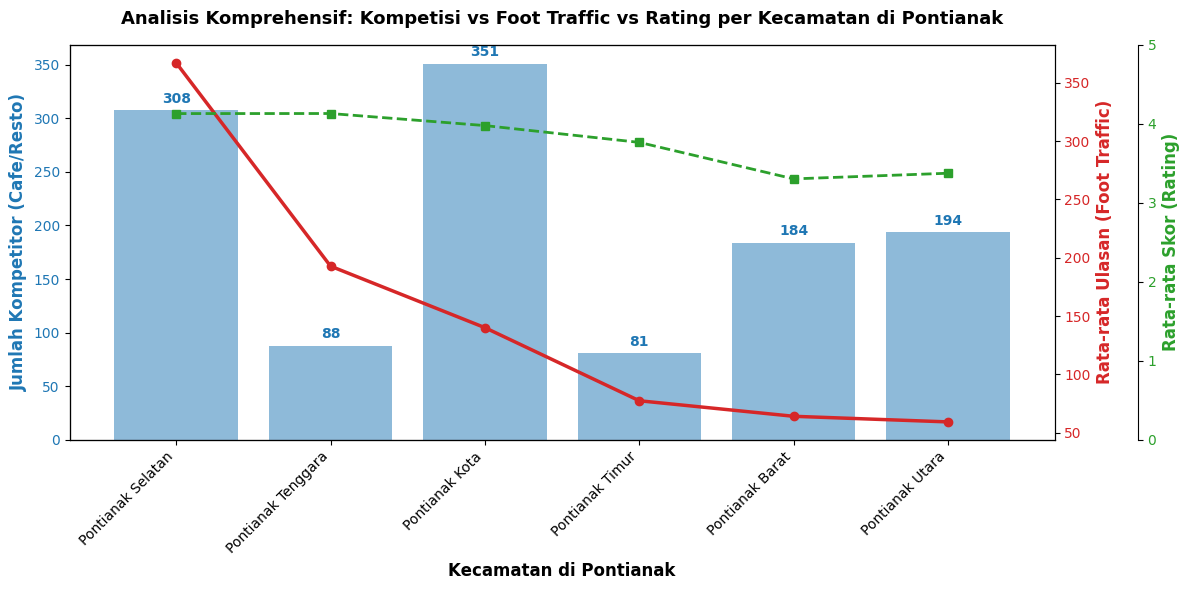

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

kecamatan_summary = df_clean.groupby('clean_kecamatan').agg(
    total_competitors=('title', 'count'),
    avg_foot_traffic=('reviewsCount', 'mean'),
    total_foot_traffic=('reviewsCount', 'sum'),
    avg_rating=('totalScore', 'mean')
).reset_index()

kecamatan_summary = kecamatan_summary.sort_values(by='avg_foot_traffic', ascending=False)
print("--- Ringkasan Analisis per Kecamatan ---")
print(kecamatan_summary)

fig, ax1 = plt.subplots(figsize=(12, 6))

color_comp = 'tab:blue'
ax1.set_xlabel('Kecamatan di Pontianak', fontsize=12, fontweight='bold')
ax1.set_ylabel('Jumlah Kompetitor (Cafe/Resto)', color=color_comp, fontsize=12, fontweight='bold')

bars = ax1.bar(kecamatan_summary['clean_kecamatan'], kecamatan_summary['total_competitors'], color=color_comp, alpha=0.5, label='Jumlah Kompetitor')
ax1.tick_params(axis='y', labelcolor=color_comp)
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    ax1.annotate(
        f'{int(height)}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center', va='bottom', fontsize=10, fontweight='bold', color=color_comp
    )

ax2 = ax1.twinx()
color_traffic = 'tab:red'
ax2.set_ylabel('Rata-rata Ulasan (Foot Traffic)', color=color_traffic, fontsize=12, fontweight='bold')
line1 = ax2.plot(kecamatan_summary['clean_kecamatan'], kecamatan_summary['avg_foot_traffic'], color=color_traffic, marker='o', linewidth=2.5, label='Avg Foot Traffic')
ax2.tick_params(axis='y', labelcolor=color_traffic)

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))

color_rating = 'tab:green'
ax3.set_ylabel('Rata-rata Skor (Rating)', color=color_rating, fontsize=12, fontweight='bold')
line2 = ax3.plot(kecamatan_summary['clean_kecamatan'], kecamatan_summary['avg_rating'], color=color_rating, marker='s', linestyle='--', linewidth=2, label='Avg Rating')
ax3.tick_params(axis='y', labelcolor=color_rating)
ax3.set_ylim(0, 5)

# Judul dan Layout
plt.title('Analisis Komprehensif: Kompetisi vs Foot Traffic vs Rating per Kecamatan di Pontianak', fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()

plt.show()

Berdasarkan analisis data jumlah kompetitor, rata-rata foot traffic, total foot traffic, dan rating, Pontianak Tenggara muncul sebagai area yang sangat strategis untuk pengembangan bisnis F&B.

Meskipun jumlah kompetitornya relatif rendah hanya 88 bisnis area ini mencatatkan rata-rata foot traffic sebesar 192,76 (tertinggi kedua setelah Pontianak Selatan) dengan akumulasi total foot traffic mencapai 16.963.

ondisi ini mengindikasikan adanya permintaan pasar yang tinggi dan potensial, namun dengan tingkat persaingan yang jauh lebih terkendali dibandingkan pusat kota seperti Pontianak Selatan atau Pontianak Kota.

Rekomendasi Aksi:
lakukan location validation di Pontianak Tenggara dengan membandingkan beberapa titik berdasarkan foot traffic aktual, jenis dan kepadatan kompetitor, harga produk, target konsumen, serta jam ramai.

## Analisis Segmentasi Pasar berdasarkan Kecamatan dan Kategori

Jenis kuliner apa yang mendominasi di suatu kecamatan di pontianak?

In [ ]:
display(df_clean['categoryName'].unique().tolist())

['Cafe',
 'Coffee shop',
 'Diner',
 'Coffee stand',
 'Chicken restaurant',
 'Deli',
 'Indonesian restaurant',
 'Seafood restaurant',
 'Family restaurant',
 'Restaurant',
 'Fried chicken takeaway',
 'Korean restaurant',
 'Padang restaurant',
 'Satay restaurant',
 'Ayam penyet restaurant',
 'Javanese restaurant',
 'Chinese noodle restaurant',
 'Brunch restaurant',
 'Ikan bakar restaurant',
 'Health food restaurant',
 'Fast food restaurant',
 'Nasi goreng restaurant',
 'Bakso restaurant',
 'Noodle shop',
 'Batak restaurant',
 'Hamburger restaurant',
 'Soto ayam restaurant',
 'Dim sum restaurant',
 'Breakfast restaurant',
 'Betawi restaurant',
 'Takoyaki restaurant',
 'Sushi restaurant',
 'Asian restaurant',
 'Art cafe',
 'Bar',
 'Shabu-shabu restaurant',
 'Chinese restaurant',
 'Soup restaurant',
 'Bakery',
 'Soup kitchen',
 'Food court',
 'Dessert restaurant',
 'Porridge restaurant',
 'Snack bar',
 'Seblak restaurant',
 'Caterer',
 'Cake shop',
 'Vegetarian restaurant',
 'Hawker center',

category masih terlalu banyak dan akan di kelompokkan berdasarkan beberapa kategori saja

In [67]:
print("""
F&B
├── Cafe
│   ├── Cafe
│   ├── Coffee Shop
│   ├── Coffee Stand
│   ├── Art Cafe
│   ├── Espresso Bar
│   ├── Diner
│   ├── Cafeteria
│   └── Bubble Tea
│
├── Restaurant & Dining
│   ├── Indonesian / Local
│   ├── Asian
│   ├── International
│   ├── Fast Food
│   ├── Chicken
│   ├── Seafood
│   ├── Family Restaurant
│   ├── Breakfast / Brunch
│   └── Other Restaurant
│
├── Street Food
│   ├── Seblak
│   ├── Takoyaki
│   ├── Kebab
│   ├── Snack Bar
│   ├── Hawker
│   └── Food Court
│
└── Bakery & Dessert
    ├── Bakery
    ├── Cake
    ├── Pastry
    ├── Dessert
    └── Ice Cream
""")


F&B
├── Cafe
│   ├── Cafe
│   ├── Coffee Shop
│   ├── Coffee Stand
│   ├── Art Cafe
│   ├── Espresso Bar
│   ├── Diner
│   ├── Cafeteria
│   └── Bubble Tea
│
├── Restaurant & Dining
│   ├── Indonesian / Local
│   ├── Asian
│   ├── International
│   ├── Fast Food
│   ├── Chicken
│   ├── Seafood
│   ├── Family Restaurant
│   ├── Breakfast / Brunch
│   └── Other Restaurant
│
├── Street Food
│   ├── Seblak
│   ├── Takoyaki
│   ├── Kebab
│   ├── Snack Bar
│   ├── Hawker
│   └── Food Court
│
└── Bakery & Dessert
    ├── Bakery
    ├── Cake
    ├── Pastry
    ├── Dessert
    └── Ice Cream



ini adalah kategori yang telah dibuat berdasarkan categoryName yang ada

In [ ]:
import pandas as pd

def map_hierarchical_categories(cat_name):
    if not isinstance(cat_name, str):
        return 'Other', 'Other'

    c = cat_name.lower()

    # --- 1. CAFE ---
    if any(x in c for x in ['coffee shop', 'coffee stand', 'espresso bar', 'bubble tea']):
        if 'coffee shop' in c: return 'Cafe', 'Coffee Shop'
        if 'coffee stand' in c: return 'Cafe', 'Coffee Stand'
        if 'espresso bar' in c: return 'Cafe', 'Espresso Bar'
        if 'bubble tea' in c: return 'Cafe', 'Bubble Tea'
    if any(x in c for x in ['cafe', 'art cafe', 'diner', 'cafeteria', 'bar', 'lounge bar', 'deli']):
        if 'art cafe' in c: return 'Cafe', 'Art Cafe'
        if 'diner' in c: return 'Cafe', 'Diner'
        if 'cafeteria' in c: return 'Cafe', 'Cafeteria'
        return 'Cafe', 'Cafe'

    # --- 3. STREET FOOD ---
    if any(x in c for x in ['seblak', 'takoyaki', 'kebab', 'snack bar', 'hawker', 'food court']):
        if 'seblak' in c: return 'Street Food', 'Seblak'
        if 'takoyaki' in c: return 'Street Food', 'Takoyaki'
        if 'kebab' in c: return 'Street Food', 'Kebab'
        if 'snack bar' in c: return 'Street Food', 'Snack Bar'
        if 'hawker' in c: return 'Street Food', 'Hawker'
        if 'food court' in c: return 'Street Food', 'Food Court'

    # --- 4. BAKERY & DESSERT ---
    if any(x in c for x in ['bakery', 'cake', 'pastry', 'dessert', 'ice cream']):
        if 'bakery' in c: return 'Bakery & Dessert', 'Bakery'
        if 'cake' in c: return 'Bakery & Dessert', 'Cake'
        if 'pastry' in c: return 'Bakery & Dessert', 'Pastry'
        if 'dessert' in c: return 'Bakery & Dessert', 'Dessert'
        if 'ice cream' in c: return 'Bakery & Dessert', 'Ice Cream'
        return 'Bakery & Dessert', 'Bakery'

    # --- 2. RESTAURANT & DINING ---
    # Breakfast / Brunch
    if any(x in c for x in ['breakfast', 'brunch']):
        return 'Restaurant & Dining', 'Breakfast / Brunch'

    # Fast Food
    if any(x in c for x in ['fast food', 'hamburger', 'pizza', 'takeout']):
        return 'Restaurant & Dining', 'Fast Food'

    # Chicken
    if any(x in c for x in ['chicken', 'fried chicken', 'ayam']):
        return 'Restaurant & Dining', 'Chicken'

    # Seafood
    if any(x in c for x in ['seafood', 'ikan bakar', 'donburi']):
        return 'Restaurant & Dining', 'Seafood'

    # Family Restaurant
    if any(x in c for x in ['family restaurant', 'buffet', 'caterer', 'food producer']):
        return 'Restaurant & Dining', 'Family Restaurant'

    # Asian
    if any(x in c for x in ['chinese', 'korean', 'japanese', 'dim sum', 'sushi', 'ramen', 'shabu-shabu', 'barbecue', 'asian']):
        return 'Restaurant & Dining', 'Asian'

    # Indonesian / Local
    if any(x in c for x in ['indonesian', 'padang', 'satay', 'javanese', 'nasi', 'bakso', 'noodle', 'batak', 'soto', 'betawi', 'sundanese', 'murtabak', 'porridge', 'soup', 'vegetarian', 'health food']):
        return 'Restaurant & Dining', 'Indonesian / Local'

    # Default Restaurant & Dining
    return 'Restaurant & Dining', 'Other Restaurant'


df_clean[['primary_category', 'sub_category']] = df_clean['categoryName'].apply(
    lambda x: pd.Series(map_hierarchical_categories(x))
)

print("--- Distribusi Primary Category ---")
print(df_clean['primary_category'].value_counts())

print("\n--- Distribusi Lengkap Primary & Sub Category ---")
print(df_clean.groupby(['primary_category', 'sub_category']).size())

--- Distribusi Primary Category ---
primary_category
Cafe                   795
Restaurant & Dining    385
Street Food             13
Bakery & Dessert        13
Name: count, dtype: int64

--- Distribusi Lengkap Primary & Sub Category ---
primary_category     sub_category      
Bakery & Dessert     Bakery                  6
                     Cake                    2
                     Dessert                 1
                     Ice Cream               3
                     Pastry                  1
Cafe                 Art Cafe                2
                     Bubble Tea              1
                     Cafe                  284
                     Cafeteria               1
                     Coffee Shop           492
                     Coffee Stand            2
                     Diner                  11
                     Espresso Bar            2
Restaurant & Dining  Asian                  62
                     Breakfast / Brunch      9
                 

In [ ]:
df_clean = df_clean.drop(columns='broad_category')

display(df_clean)


,title,categoryName,categories,neighborhood,address,location,reviewsCount,totalScore,clean_kecamatan,primary_category,sub_category
0,Warkop JUANDA Pontianak,Cafe,"[Cafe, Coffee shop]","Darat Sekip, Pontianak Kota","Jl. Ir. H. Juanda No.64, Darat Sekip, Kec. Pon...","{'lat': -0.0266244, 'lng': 109.3396075}",14.0,4.6,Pontianak Kota,Cafe,Cafe
1,Warkop MC-O,Cafe,[Cafe],"Sungai Jawi Dalam, Pontianak Barat","Gg. H.M. Husin No.5, Sungai Jawi Dalam, Kec. P...","{'lat': -0.0229043, 'lng': 109.307907}",19.0,4.8,Pontianak Barat,Cafe,Cafe
2,Warkop Doeloe Pontianak,Coffee shop,[Coffee shop],"Sungai Jawi, Pontianak Kota","Jl. Putri Dara Hitam No.1a, Sungai Jawi, Kec. ...","{'lat': -0.025736799999999997, 'lng': 109.3228...",30.0,4.6,Pontianak Kota,Cafe,Coffee Shop
3,Warkop Pelabuhan,Coffee shop,[Coffee shop],"Tengah, Pontianak Kota","Jl. Pak Kasih No.8, Tengah, Kec. Pontianak Kot...","{'lat': -0.020865599999999998, 'lng': 109.3364...",130.0,4.4,Pontianak Kota,Cafe,Coffee Shop
4,Warkop 28,Cafe,"[Cafe, Coffee shop]","Sungai Jawi Luar, Pontianak Barat","X8Q7+8F5, Sungai Jawi Luar, Pontianak Barat, P...","{'lat': -0.0117332, 'lng': 109.3137278}",328.0,4.3,Pontianak Barat,Cafe,Cafe
...,...,...,...,...,...,...,...,...,...,...,...
1245,SAMWON PONTIANAK,Takeout Restaurant,[Takeout Restaurant],"Central Siantan, Pontianak Utara","Gg. Selat Karimata II No.2 No.F8, Siantan Teng...","{'lat': -0.0190174, 'lng': 109.34549}",0.0,0.0,Pontianak Utara,Restaurant & Dining,Fast Food
1246,Ayam Gepuk Djogja Siantan,Indonesian restaurant,[Indonesian restaurant],"Central Siantan, Pontianak Utara","X8JW+H4X, Jl. Gusti Situt Mahmud, Siantan Teng...","{'lat': -0.018521299999999997, 'lng': 109.3453...",29.0,3.6,Pontianak Utara,Restaurant & Dining,Indonesian / Local
1247,Kedai Bakmi dan Nasi Ayam 33,Chinese restaurant,[Chinese restaurant],"Darat Sekip, Pontianak Kota","X8FQ+855, Jl. A. R. Hakim, Darat Sekip, Kec. P...","{'lat': -0.0267332, 'lng': 109.3379934}",0.0,0.0,Pontianak Kota,Restaurant & Dining,Asian
1248,Nasi Kari lorong Serayu,Chinese restaurant,[Chinese restaurant],"Darat Sekip, Pontianak Kota","Jl. Serayu No.49, Darat Sekip, Kec. Pontianak ...","{'lat': -0.0246509, 'lng': 109.3427654}",0.0,0.0,Pontianak Kota,Restaurant & Dining,Asian


--- Ringkasan Segmentasi Kecamatan & Primary Category ---
       clean_kecamatan     primary_category  total_business
0      Pontianak Barat     Bakery & Dessert               1
1      Pontianak Barat                 Cafe             147
2      Pontianak Barat  Restaurant & Dining              35
3      Pontianak Barat          Street Food               1
4       Pontianak Kota     Bakery & Dessert               3
5       Pontianak Kota                 Cafe             232
6       Pontianak Kota  Restaurant & Dining             113
7       Pontianak Kota          Street Food               3
8    Pontianak Selatan     Bakery & Dessert               3
9    Pontianak Selatan                 Cafe             180
10   Pontianak Selatan  Restaurant & Dining             122
11   Pontianak Selatan          Street Food               3
12  Pontianak Tenggara     Bakery & Dessert               1
13  Pontianak Tenggara                 Cafe              45
14  Pontianak Tenggara  Restaurant & Dinin

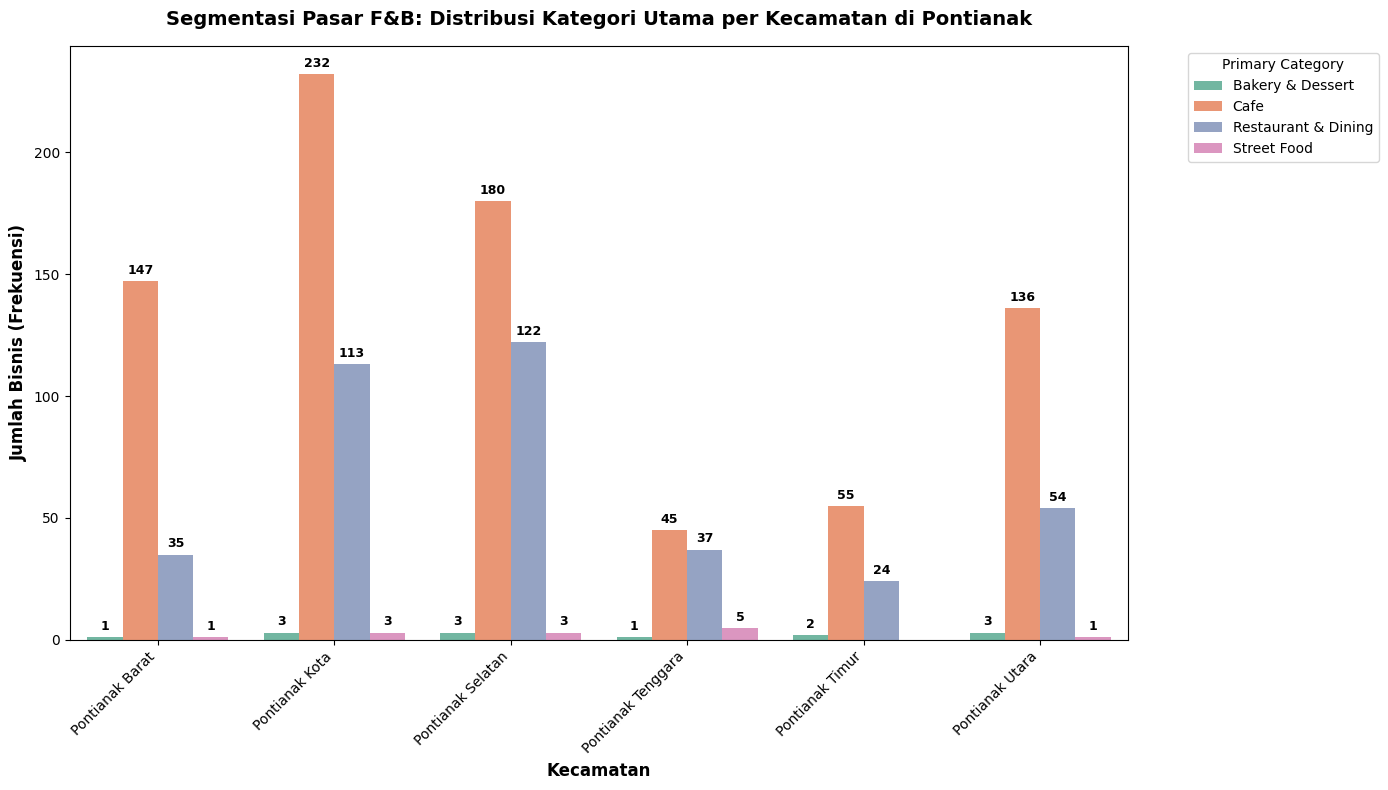

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Agregasi data berdasarkan Kecamatan dan Primary Category
segmentation_summary = df_clean.groupby(['clean_kecamatan', 'primary_category']).agg(
    total_business=('title', 'count')
).reset_index()

print("--- Ringkasan Segmentasi Kecamatan & Primary Category ---")
print(segmentation_summary)

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=segmentation_summary,
    x='clean_kecamatan',
    y='total_business',
    hue='primary_category',
    palette='Set2'
)

plt.title('Segmentasi Pasar F&B: Distribusi Kategori Utama per Kecamatan di Pontianak', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kecamatan', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Bisnis (Frekuensi)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')

plt.legend(title='Primary Category', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

for p in ax.patches:
    height = p.get_height()
    if height > 0 and not pd.isna(height):
        ax.annotate(
            f'{int(height)}',
            xy=(p.get_x() + p.get_width() / 2., height),
            xytext=(0, 3),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold',
            rotation=0
        )

plt.tight_layout()
plt.show()

Daru semua kategori, 2 kategori sangat mendominasi setiap kecamatan, dan yang paling tinggi yaitu cafe, hal ini membuktikan mengenai fenomena Pontianak adalah 'tempat ngopi' dengan istilah '1001 coffe shop/warkop'

In [69]:
import pandas as pd

# Agregasi performa berdasarkan Primary Category
category_performance = df_clean.groupby('primary_category').agg(
    total_venues=('title', 'count'),
    avg_foot_traffic=('reviewsCount', 'mean'),
    total_foot_traffic=('reviewsCount', 'sum'),
    avg_rating=('totalScore', 'mean')
).reset_index()

category_performance = category_performance.sort_values(by='avg_foot_traffic', ascending=False)

print("--- Performa Kategori Utama (Rating & Foot Traffic) ---")
print(category_performance)

--- Performa Kategori Utama (Rating & Foot Traffic) ---
      primary_category  total_venues  avg_foot_traffic  total_foot_traffic  \
0     Bakery & Dessert            13        429.153846              5579.0   
2  Restaurant & Dining           385        285.018182            109732.0   
3          Street Food            13        199.769231              2597.0   
1                 Cafe           795        114.225157             90809.0   

   avg_rating  
0    4.330769  
2    4.123117  
3    4.061538  
1    3.651321  


--- Tabel Analisis Detail Per Kecamatan & Per Kategori ---


,clean_kecamatan,primary_category,jumlah_bisnis,rata_rata_foot_traffic,total_foot_traffic,rata_rata_rating
0,Pontianak Barat,Bakery & Dessert,1,482.000000,482.0,4.500000
2,Pontianak Barat,Restaurant & Dining,35,158.171429,5536.0,4.234286
1,Pontianak Barat,Cafe,147,39.136054,5753.0,3.065986
3,Pontianak Barat,Street Food,1,9.000000,9.0,4.400000
6,Pontianak Kota,Restaurant & Dining,113,235.876106,26654.0,4.206195
4,Pontianak Kota,Bakery & Dessert,3,162.000000,486.0,4.500000
5,Pontianak Kota,Cafe,232,94.202586,21855.0,3.856034
7,Pontianak Kota,Street Food,3,50.333333,151.0,4.300000
8,Pontianak Selatan,Bakery & Dessert,3,1518.000000,4554.0,4.766667
10,Pontianak Selatan,Restaurant & Dining,122,512.540984,62530.0,4.149180


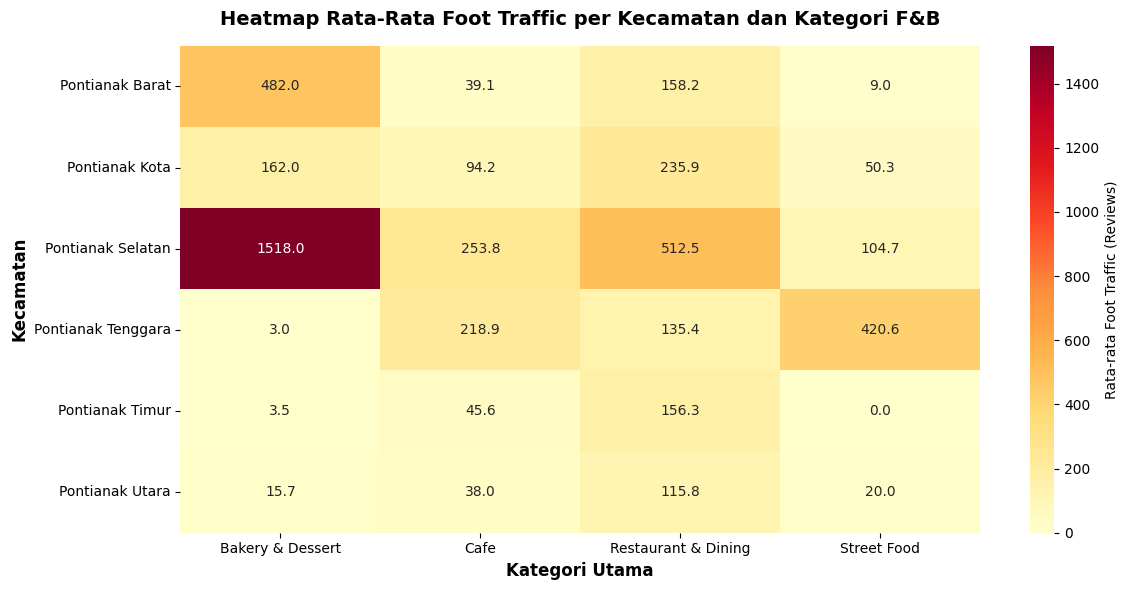

In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Melakukan agregasi data berdasarkan kecamatan dan kategori utama
district_category_summary = df_clean.groupby(['clean_kecamatan', 'primary_category']).agg(
    jumlah_bisnis=('title', 'count'),
    rata_rata_foot_traffic=('reviewsCount', 'mean'),
    total_foot_traffic=('reviewsCount', 'sum'),
    rata_rata_rating=('totalScore', 'mean')
).reset_index()

print("--- Tabel Analisis Detail Per Kecamatan & Per Kategori ---")
display(district_category_summary.sort_values(by=['clean_kecamatan', 'rata_rata_foot_traffic'], ascending=[True, False]))

# 2. Membuat Pivot Table untuk visualisasi perbandingan Rata-rata Foot Traffic
pivot_traffic = district_category_summary.pivot(
    index='clean_kecamatan',
    columns='primary_category',
    values='rata_rata_foot_traffic'
).fillna(0)

# 3. Visualisasi Heatmap untuk memudahkan membaca peluang pasar
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_traffic, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Rata-rata Foot Traffic (Reviews)'})
plt.title('Heatmap Rata-Rata Foot Traffic per Kecamatan dan Kategori F&B', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kategori Utama', fontsize=12, fontweight='bold')
plt.ylabel('Kecamatan', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

kita cek toko apa dan dimana yang memiliki foot traffic tinggi ini

In [70]:
import pandas as pd

bakery_dessert_df = df_clean[df_clean['primary_category'] == 'Bakery & Dessert'].copy()

bakery_dessert_df = bakery_dessert_df.sort_values(by='reviewsCount', ascending=False)

print(f"Total venue Bakery & Dessert: {len(bakery_dessert_df)}")
display(bakery_dessert_df[['title', 'categoryName', 'clean_kecamatan', 'reviewsCount', 'totalScore', 'address']])

Total venue Bakery & Dessert: 13


,title,categoryName,clean_kecamatan,reviewsCount,totalScore,address
841,Es Krim Angi,Ice cream shop,Pontianak Selatan,4520.0,4.6,"Jl. Karel Satsuit Tubun No.8, Akcaya, Kec. Pon..."
348,Es Teler Jeranding,Dessert restaurant,Pontianak Barat,482.0,4.5,"X8M8+GHX, Jl. Re.Martadinata, Sungai Jawi Dala..."
880,Es buah seroja,Ice cream shop,Pontianak Kota,366.0,4.1,"X85G+F9Q, Jl. Slt. Abdurrahman, Sungai Bangkon..."
408,D'Bread Recipe,Bakery,Pontianak Kota,104.0,4.6,"X8HC+Q7J, Sungai Jawi Dalam, Pontianak Kota, P..."
409,Roti'A Siantan,Bakery,Pontianak Utara,36.0,4.8,"Jl. Gusti Situt Mahmud No.37, Siantan Hulu, Ke..."
873,Bingke Al Fajar,Pastry shop,Pontianak Selatan,18.0,4.7,"Jl. Prof. M.Yamin No.6, Kota Baru, Kec. Pontia..."
664,Aikuki Bakery & Cafe,Bakery,Pontianak Selatan,16.0,5.0,"Seberang Immanuel IBC, Jl. Letnan Jendral Suto..."
814,Rumah Kuliner Yuli Supandi,Bakery,Pontianak Kota,16.0,4.8,"Gg. Nurcahaya No.24, Sungai Bangkong, Kec. Pon..."
325,Kuliner Jolin,Bakery,Pontianak Utara,11.0,4.9,"Jalan parit parwasal No.02, Central Siantan, P..."
410,Liana Kuliner,Cake shop,Pontianak Timur,4.0,4.3,"Jl. Ya' M. Sabran Gang Masjid Nurulsalam No.5,..."


setelah di cek tingginya foot traffic dan rating pada kategori Bakery & Dessert terdorong oleh fenomena outlier, di mana beberapa destinasi legendaris seperti Es Krim Angi dan Es Teler Jeranding menarik ribuan ulasan sebagai pusat kuliner ikonis yang wajib dikunjungi wisatawan luar Pontianak.

In [74]:
import folium
from folium.plugins import MarkerCluster
import pandas as pd
import numpy as np

# ============================================================
# 1. PREPARE DATA
# ============================================================

def extract_lat_lng(loc):
    if isinstance(loc, dict):
        return loc.get('lat'), loc.get('lng')
    return None, None


df_map = df_clean.copy()

# Extract latitude & longitude
df_map['latitude'], df_map['longitude'] = zip(
    *df_map['location'].apply(extract_lat_lng)
)

# Pastikan reviewsCount dan totalScore numeric
df_map['reviewsCount'] = pd.to_numeric(
    df_map['reviewsCount'],
    errors='coerce'
)

df_map['totalScore'] = pd.to_numeric(
    df_map['totalScore'],
    errors='coerce'
)

# Hapus data tanpa koordinat / kecamatan
df_map = df_map.dropna(
    subset=[
        'latitude',
        'longitude',
        'clean_kecamatan'
    ]
)

# ============================================================
# 2. AGGREGATE F&B PERFORMANCE PER KECAMATAN
# ============================================================

district_summary = (
    df_map
    .groupby('clean_kecamatan')
    .agg(
        total_competitors=('title', 'count'),

        # reviewsCount sebagai proxy foot traffic
        avg_foot_traffic=('reviewsCount', 'mean'),
        total_foot_traffic=('reviewsCount', 'sum'),

        avg_rating=('totalScore', 'mean'),

        # Titik tengah geografis kecamatan
        latitude=('latitude', 'mean'),
        longitude=('longitude', 'mean')
    )
    .reset_index()
)

# ============================================================
# 3. DEFINE COMPETITION LEVEL
# ============================================================

# Berdasarkan jumlah competitor
district_summary['competition_level'] = pd.qcut(
    district_summary['total_competitors'],
    q=3,
    labels=[
        'Low Competition',
        'Medium Competition',
        'High Competition'
    ]
)

competition_colors = {
    'Low Competition': 'green',
    'Medium Competition': 'orange',
    'High Competition': 'red'
}

# ============================================================
# 4. CREATE MAP
# ============================================================

pontianak_center = [-0.026330, 109.342504]

m = folium.Map(
    location=pontianak_center,
    zoom_start=12,
    tiles='CartoDB positron'
)

# ============================================================
# 5. ADD KECAMATAN BUBBLES
# ============================================================

for _, row in district_summary.iterrows():

    competition = row['competition_level']
    color = competition_colors[competition]

    # --------------------------------------------------------
    # Bubble size = Average Foot Traffic
    # Foot Traffic = reviewsCount
    # --------------------------------------------------------

    radius = 8 + np.sqrt(
        row['avg_foot_traffic']
    ) * 1.2

    # --------------------------------------------------------
    # Popup
    # --------------------------------------------------------

    popup_html = f"""
    <div style="
        font-family: Arial;
        width: 270px;
        line-height: 1.5;
    ">

        <h4 style="
            margin-bottom: 8px;
            margin-top: 5px;
        ">
            {row['clean_kecamatan']}
        </h4>

        <hr>

        <b>Competition:</b>
        <span style="color:{color};">
            {competition}
        </span>

        <br><br>

        <b>Total Competitors:</b><br>
        {int(row['total_competitors'])}

        <br><br>

        <b>Avg Foot Traffic:</b><br>
        {row['avg_foot_traffic']:,.2f}

        <br>
        <small>
        Average Reviews per Venue
        </small>

        <br><br>

        <b>Total Foot Traffic:</b><br>
        {row['total_foot_traffic']:,.0f}

        <br>
        <small>
        Total Reviews
        </small>

        <br><br>

        <b>Average Rating:</b><br>
        {row['avg_rating']:.2f}

        <hr>

        <small>
        Foot Traffic is proxied by Reviews Count.
        </small>

    </div>
    """

    # --------------------------------------------------------
    # Tooltip
    # --------------------------------------------------------

    tooltip_text = f"""
    <b>{row['clean_kecamatan']}</b><br>
    Competitors: {int(row['total_competitors'])}<br>
    Avg Foot Traffic: {row['avg_foot_traffic']:,.1f}<br>
    Avg Rating: {row['avg_rating']:.2f}
    """

    # --------------------------------------------------------
    # Circle
    # --------------------------------------------------------

    folium.CircleMarker(
        location=[
            row['latitude'],
            row['longitude']
        ],

        radius=radius,

        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.45,

        weight=2,

        tooltip=folium.Tooltip(
            tooltip_text
        ),

        popup=folium.Popup(
            popup_html,
            max_width=320
        )
    ).add_to(m)


# ============================================================
# 6. INDIVIDUAL BUSINESS LAYER
# ============================================================

business_layer = folium.FeatureGroup(
    name='Individual Businesses',
    show=False
)

# Warna berdasarkan primary category
category_colors = {
    'Cafe': 'blue',
    'Restaurant & Dining': 'orange',
    'Street Food': 'red',
    'Bakery & Dessert': 'green',
    'Other': 'gray'
}

# Marker cluster
cluster = MarkerCluster().add_to(
    business_layer
)

for _, row in df_map.iterrows():

    cat = row.get(
        'primary_category',
        'Other'
    )

    color = category_colors.get(
        cat,
        'gray'
    )

    reviews = row.get(
        'reviewsCount',
        0
    )

    # --------------------------------------------------------
    # Business Popup
    # --------------------------------------------------------

    popup_text = f"""
    <div style="
        font-family: Arial;
        width: 250px;
        line-height: 1.5;
    ">

        <b>{row['title']}</b>

        <hr>

        <b>Category:</b><br>
        {cat}

        <br><br>

        <b>District:</b><br>
        {row['clean_kecamatan']}

        <br><br>

        <b>Rating:</b><br>
        {row['totalScore']}

        <br><br>

        <b>Reviews:</b><br>
        {int(reviews)}

        <br><br>

        <b>Address:</b><br>
        {row['address']}

    </div>
    """

    folium.CircleMarker(
        location=[
            row['latitude'],
            row['longitude']
        ],

        radius=4,

        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.65,

        popup=folium.Popup(
            popup_text,
            max_width=300
        )
    ).add_to(cluster)

business_layer.add_to(m)


# ============================================================
# 7. LEGEND
# ============================================================

legend_html = """
<div style="
    position: fixed;
    bottom: 40px;
    left: 40px;
    width: 260px;
    background-color: white;
    border: 2px solid #777;
    z-index: 9999;
    font-size: 13px;
    padding: 12px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.2);
">

    <b style="font-size:15px;">
        F&B Market Map
    </b>

    <hr>

    <b>Competition Level</b><br>

    <span style="color:green;">●</span>
    Low Competition<br>

    <span style="color:orange;">●</span>
    Medium Competition<br>

    <span style="color:red;">●</span>
    High Competition

    <br><br>

    <b>Bubble Size</b><br>
    Larger = Higher Avg Foot Traffic

    <br><br>

    <b>Foot Traffic Proxy</b><br>
    Reviews Count

    <br><br>

    <small>
    Click a bubble to see district metrics.
    </small>

</div>
"""

m.get_root().html.add_child(
    folium.Element(legend_html)
)


# ============================================================
# 8. LAYER CONTROL
# ============================================================

folium.LayerControl(
    collapsed=False
).add_to(m)


# ============================================================
# 9. DISPLAY MAP
# ============================================================

m

# Konklusi

### **Kesimpulan Strategis & Rekomendasi Bisnis (F&B Market Analysis Pontianak)**

Berdasarkan hasil analisis data komprehensif terhadap **1.206 bisnis aktif** di Pontianak, berikut adalah jawaban strategis untuk menjawab beberapa pertanyaan:

---

#### **1. Di kecamatan mana peluang terbaik untuk membuka bisnis F&B baru?**

**Rekomendasi Utama: Pontianak Tenggara**
* **Mengapa?** Kecamatan ini memiliki **rasio suplai-permintaan paling sehat**.
  * **Kompetisi Rendah:** Hanya memiliki **88 kompetitor** (jauh lebih sedikit dibandingkan pusat keramaian utama seperti Pontianak Kota dengan 351 outlet dan Pontianak Selatan dengan 308 outlet).
  * **Kunjungan Pelanggan (Foot Traffic) Tinggi:** Mencatatkan **rata-rata 192.76 ulasan per outlet** (tertinggi kedua setelah Pontianak Selatan). Hal ini mengindikasikan pasar lokal di Pontianak Tenggara sangat aktif, haus akan opsi kuliner baru, tetapi belum jenuh.
  * **Tingkat Kepuasan Tinggi:** Rata-rata rating di kawasan ini mencapai **4.13**, menandakan ekspektasi kualitas yang tinggi dari konsumen lokal.

---

#### **2. Kategori F&B apa yang sebaiknya dibuka dan di mana lokasinya?**

##### **Opsi A: Membuka Restoran Modern / Akses Cepat di Pontianak Tenggara**
* **Rekomendasi Bisnis:** *Restaurant & Dining* (khususnya sub-kategori makanan lokal modern, kuliner Asia populer seperti ramen/dimsum, atau hidangan ayam/fast-food berkualitas).
* **Analisis Peluang:**
  * Dominasi pasar di Pontianak Tenggara saat ini masih diduduki oleh format **Cafe/Warkop (45 outlet)** dan **Restaurant & Dining (37 outlet)**.
  * Dibandingkan dengan tren kejenuhan industri kopi (Cafe/Warkop) di Pontianak secara keseluruhan, kategori **Restaurant & Dining secara konsisten menarik rata-rata foot traffic yang jauh lebih masif (285 ulasan per outlet)** dibandingkan Cafe biasa (hanya 114 ulasan per outlet).
  * Membuka restoran dengan target keluarga muda, pekerja kantoran, dan mahasiswa di Pontianak Tenggara akan memberikan tingkat keberhasilan jangka panjang yang lebih tinggi.

##### **Opsi B: Membuka Dessert Premium / Toko Roti Khusus di Pontianak Kota atau Pontianak Selatan**
* **Rekomendasi Bisnis:** *Bakery & Dessert* (seperti artisan bakery, gelato shop, atau modern dessert house).
* **Analisis Peluang:**
  * Kategori **Bakery & Dessert** adalah permata tersembunyi (*under-served market*) dengan **rata-rata foot traffic tertinggi di Pontianak (429.15 ulasan per outlet)** dan kepuasan pelanggan tertinggi (**4.33 **).
  * Meskipun didorong oleh beberapa destinasi legendaris ikonik (seperti Es Krim Angi) **bold text**, angka ini membuktikan adanya ketertarikan masif dari masyarakat Pontianak terhadap hidangan manis (*dessert*).
  * Membuka unit usaha dessert yang modern dan memiliki estetika visual menarik (*instagramable*) di perbatasan **Pontianak Selatan atau Pontianak Kota** akan langsung memikat demografi anak muda dan keluarga yang mencari alternatif selain warkop biasa.